# 1. Variant quality control

This section prepares masked genomic regions and performs QC for SNPs, indels, and SVs.

## 1.1 Preparation of masked-region BED files

- `chm13v2.0_censat_v2.1.bed`
  - https://s3-us-west-2.amazonaws.com/human-pangenomics/T2T/CHM13/assemblies/annotation/chm13v2.0_censat_v2.1.bed
- `chm13v2.0_RepeatMasker_4.1.2p1.2022Apr14.bed`
  - https://s3-us-west-2.amazonaws.com/human-pangenomics/T2T/CHM13/assemblies/annotation/chm13v2.0_RepeatMasker_4.1.2p1.2022Apr14.bed
- `chm13v2.0_SD.full.bed`
  - https://s3-us-west-2.amazonaws.com/human-pangenomics/T2T/CHM13/assemblies/annotation/chm13v2.0_SD.full.bed

Reference example: Ghorbani, M., Moosa, S., Siddig, Z. et al. Near-complete Middle Eastern genomes refine autozygosity and enhance disease-causing and population-specific variant discovery. *Nature Genetics* 57, 1119–1131 (2025). https://doi.org/10.1038/s41588-025-02173-7

In [ ]:
import sys

def parse_bed_file(filename, file_type='generic'):
    """
    Read a BED file and return intervals as [(chrom, start, end), ...].
    file_type: either 'generic' or 'repeatmasker'.
    """
    intervals = []
    # Define RepeatMasker classes to retain.
    # Note: this uses exact matching. If entries such as "Satellite/centromeric" are present, switch to substring matching.
    target_classes = {'Low_complexity', 'rRNA', 'Satellite'}
    
    try:
        with open(filename, 'r') as f:
            for line_num, line in enumerate(f):
                # Skip comment lines and empty lines.
                if line.startswith('#') or line.startswith('track') or line.startswith('browser') or not line.strip():
                    continue
                
                parts = line.strip().split()
                if len(parts) < 3:
                    continue
                
                chrom = parts[0]
                try:
                    start = int(parts[1])
                    end = int(parts[2])
                except ValueError:
                    continue

                # --- RepeatMasker-specific filtering ---
                if file_type == 'repeatmasker':
                    # Example row: chr1  41543  41632  MLT1K  263  +  LTR  ERVL-MaLR ...
                    # Column 1 is chromosome (index 0).
                    # ...
                    # Column 7 is class (index 6).
                    if len(parts) > 6:
                        rep_class = parts[6]
                        # Retain only the specified classes.
                        if rep_class not in target_classes:
                            continue
                    else:
                        # If column 7 is absent, skip the row by default; standard RepeatMasker BED files usually include this field.
                        continue

                intervals.append((chrom, start, end))
                
        print(f"Loaded {len(intervals)} intervals from {filename}")
        return intervals
    except FileNotFoundError:
        print(f"Error: File {filename} not found.")
        return []

def merge_intervals(intervals):
    """
    Sort intervals and merge overlapping intervals.
    """
    if not intervals:
        return []

    # Sort by chromosome and start position.
    intervals.sort(key=lambda x: (x[0], x[1]))

    merged = []
    if not intervals:
        return merged

    # Initialize the first interval.
    current_chrom, current_start, current_end = intervals[0]

    for i in range(1, len(intervals)):
        next_chrom, next_start, next_end = intervals[i]

        if next_chrom == current_chrom:
            # Merge if intervals overlap or are adjacent (next_start <= current_end).
            if next_start <= current_end:
                current_end = max(current_end, next_end)
            else:
                merged.append((current_chrom, current_start, current_end))
                current_chrom, current_start, current_end = next_chrom, next_start, next_end
        else:
            merged.append((current_chrom, current_start, current_end))
            current_chrom, current_start, current_end = next_chrom, next_start, next_end

    # Add the final interval.
    merged.append((current_chrom, current_start, current_end))
    
    return merged

def write_bed(intervals, output_filename):
    """
    Write merged intervals to a file.
    """
    with open(output_filename, 'w') as f:
        for chrom, start, end in intervals:
            f.write(f"{chrom}\t{start}\t{end}\n")
    print(f"Wrote merged intervals to {output_filename}")

def main():
    # Define input and output file names.
    file_censat = 'chm13v2.0_censat_v2.1.bed'
    file_rm = 'chm13v2.0_RepeatMasker_4.1.2p1.2022Apr14.bed'
    file_sd = 'chm13v2.0_SD.full.bed'
    output_file = 'CHM13_masker.bed'

    all_intervals = []

    # 1. Read CenSat annotations without filtering.
    print("Reading CenSat file...")
    all_intervals.extend(parse_bed_file(file_censat))

    # 2. Read segmental-duplication annotations without filtering.
    print("Reading SD file...")
    all_intervals.extend(parse_bed_file(file_sd))

    # 3. Read RepeatMasker annotations and retain only Low_complexity, rRNA, and Satellite entries.
    print("Reading RepeatMasker file (filtering for Low_complexity, rRNA, Satellite)...")
    all_intervals.extend(parse_bed_file(file_rm, file_type='repeatmasker'))

    # 4. Merge intervals.
    print("Sorting and merging intervals...")
    merged_intervals = merge_intervals(all_intervals)

    # 5. Write output.
    write_bed(merged_intervals, output_file)

if __name__ == "__main__":
    main()

## 1.2 SNP/indel QC

### 1.2.1 SNP/indel MAF and missingness QC

In [ ]:
%%bash
dir=07_sindel

vcf=/home/s3020226030/1_rSV/01_human_chm13/pangenie_chm13_all_decomposed_lenient.vcf.gz

bcftools view "$vcf" -Ov \
| awk '
    BEGIN {
        OFS = "\t";
        i = 1;
    }

    # Preserve the header.
    /^##/ { print; next }
    /^#CHROM/ { print; next }

    {
        id = $3;
        chr = $1;
        n = split(id, a, "-");
        type = (n >= 3 ? a[3] : "");

        # --- Compute allele length difference ---
        # If multiple ALT alleles are present, use the first one.
        split($5, alt_arr, ",");
        alt = alt_arr[1];

        # Symbolic alleles in angle brackets are not considered here.
        len_diff = length($4) - length(alt);
        if (len_diff < 0) len_diff = -len_diff;

        # Exclude variants with length difference >= 50 bp.
        if (len_diff >= 50) next;

        # Keep CHROM unchanged.
        # Clear the INFO field.
        $8 = ".";

        # Rename variant IDs.
        if (len_diff == 0) {
            $3 = "SNP_" chr "_" i;
        } else if (len_diff > 0) {
            $3 = "indel_" chr "_" i;
        }

        i++;

        print;
    }
' \
| bgzip -c > ${dir}/sindel.vcf.gz

bcftools index -t ${dir}/sindel.vcf.gz --threads 20

## This generates `sindel.vcf.gz`, containing only SNPs/indels with renamed IDs. The X chromosome still needs to be removed.

In [ ]:
%%bash
## _QCed.95 vcf , keep samples, prune
# QC
bcftools view 07_sindel/sindel.vcf.gz \
  | bcftools +setGT -- -t q -n . -i 'FMT/GQ<20' \
  | tee >(bcftools view -i 'MAF>=0.01 && F_MISSING<=0.05' -Oz -o 07_sindel/sindel_QCed.95.vcf.gz) \
  >/dev/null


In [ ]:
%%bash
plink --vcf 07_sindel/sindel_QCed.95.vcf.gz --keep-allele-order --maf 0.01 --geno 0.05 --keep keep_samples_plink.txt \
    --make-bed --out 07_sindel/sindel_QCed.95 --autosome

In [ ]:
%%bash
dir=07_sindel
mkdir -p ${dir}

# --- Path configuration ---
vcf_input="/home/s3020226030/1_rSV/01_human_chm13/pangenie_chm13_all_decomposed_lenient.vcf.gz"
samples_plink="keep_samples_plink.txt"
samples_bcftools="${dir}/samples_for_bcftools.txt"
masker_bed="CHM13_masker.bed"  # Ensure this file is in the current directory or provide an absolute path.

# 1. Prepare a bcftools-compatible sample list using only column 2 (IID).
awk '{print $2}' ${samples_plink} > ${samples_bcftools}

echo "Step 1: Processing VCF (Rename IDs, Subset Samples, Filter GQ)..."

# -----------------------------------------------------------
# bcftools pipeline:
# 1. view -Ov: stream uncompressed VCF.
# 2. awk: rename IDs with chromosome-specific counters, filter variants >= 50 bp, and clear INFO.
# 3. view -S: subset to 731 samples.
# 4. setGT: set genotypes with GQ < 20 to missing.
# 5. bgzip: compress the output for PLINK.
# -----------------------------------------------------------
bcftools view "${vcf_input}" -Ov \
| awk '
    BEGIN { OFS = "\t"; i = 1; prev_chr = ""; }
    /^##/ { print; next }
    /^#CHROM/ { print; next }
    {
        if ($1 != prev_chr) { i = 1; prev_chr = $1; } # Reset the counter when the chromosome changes.

        split($5, alt_arr, ","); alt = alt_arr[1];
        if (alt ~ /^<.*>$/) next; # Exclude symbolic alleles.

        len_diff = length($4) - length(alt);
        if (len_diff < 0) len_diff = -len_diff;
        if (len_diff >= 50) next; # Exclude SVs.

        $8 = "."; # Clear INFO.
        # Rename IDs.
        type = (len_diff == 0) ? "SNP" : "indel";
        $3 = type "_" $1 "_" i;
        
        i++;
        print;
    }
' \
| bcftools view -S ${samples_bcftools} --force-samples -Ou \
| bcftools +setGT -- -t q -n . -i 'FMT/GQ<20' \
| bgzip -c > ${dir}/sindel_731_preQC.vcf.gz

echo "Step 2: PLINK QC (Filter MAF/Geno, Exclude Mask, Autosome)..."


In [ ]:
%%bash
dir=07_sindel
mkdir -p ${dir}
# --- Path configuration ---
vcf_input="/home/s3020226030/1_rSV/01_human_chm13/pangenie_chm13_all_decomposed_lenient.vcf.gz"
samples_plink="keep_samples_plink.txt"
samples_bcftools="${dir}/samples_for_bcftools.txt"
masker_bed="CHM13_masker.bed"  # Ensure this file is in the current directory or provide an absolute path.
# -----------------------------------------------------------
# PLINK pipeline:
# Read the previous VCF, apply MAF/missingness filters, remove masked regions, retain autosomes, and output PLINK BED files.
# -----------------------------------------------------------
plink --vcf ${dir}/sindel_731_preQC.vcf.gz \
      --keep-allele-order \
      --autosome \
      --exclude range ${masker_bed} \
      --maf 0.01 \
      --geno 0.05 \
      --make-bed \
      --out ${dir}/sindel_QCed_final

# Remove intermediate files (optional).
# rm ${dir}/sindel_731_preQC.vcf.gz
# rm ${samples_bcftools}

echo "Done! Output: ${dir}/sindel_QCed_final.bed"
echo "Ready for GCTA cis-heritability analysis."

### 1.2.2 SNP/indel filtering by CHM13 masked regions

In [ ]:
import sys
import bisect
import os

# --- Path configuration ---
BIM_FILE = '07_sindel/sindel_QCed_final2.bim'
MASK_BED = 'CHM13_masker.bed'
OUT_DIR = '07_sindel'
OUT_SNP = os.path.join(OUT_DIR, 'valid_snps.txt')     # IDs of retained SNPs.
OUT_INDEL = os.path.join(OUT_DIR, 'valid_indels.txt') # IDs of retained indels.

def normalize_chrom(chrom):
    """Standardize chromosome names."""
    return str(chrom).lower().replace('chr', '')

def load_mask(bed_path):
    """Read BED intervals and build an interval table."""
    print(f"Loading mask file: {bed_path} ...")
    mask_data = {}
    count = 0
    with open(bed_path, 'r') as f:
        for line in f:
            if line.startswith('#') or not line.strip(): continue
            parts = line.strip().split()
            if len(parts) < 3: continue
            
            chrom = normalize_chrom(parts[0])
            try:
                start = int(parts[1])
                end = int(parts[2])
            except ValueError: continue
            
            if chrom not in mask_data:
                mask_data[chrom] = {'starts': [], 'ends': []}
            
            mask_data[chrom]['starts'].append(start)
            mask_data[chrom]['ends'].append(end)
            count += 1
            
    # Ensure intervals are sorted by start position.
    for chrom in mask_data:
        combined = sorted(zip(mask_data[chrom]['starts'], mask_data[chrom]['ends']))
        mask_data[chrom]['starts'] = [x[0] for x in combined]
        mask_data[chrom]['ends'] = [x[1] for x in combined]

    print(f"Loaded {count} mask intervals.")
    return mask_data

def is_overlapping(chrom, v_start, v_end, mask_data):
    """Check whether variant interval [v_start, v_end) overlaps masked regions."""
    if chrom not in mask_data: return False
    starts = mask_data[chrom]['starts']
    ends = mask_data[chrom]['ends']
    
    idx = bisect.bisect_right(starts, v_start)
    
    # Check the previous interval.
    if idx > 0:
        if ends[idx - 1] > v_start: return True
    # Check the current interval.
    if idx < len(starts):
        if starts[idx] < v_end: return True
            
    return False

def process_bim():
    print(f"Processing BIM: {BIM_FILE} with Interval Overlap Check ...")
    mask_db = load_mask(MASK_BED)
    
    stats = {
        'total': 0,
        'snp_kept': 0, 'snp_removed': 0,
        'indel_kept': 0, 'indel_removed': 0,
        'other_ignored': 0 
    }
    
    with open(BIM_FILE, 'r') as f_in, \
         open(OUT_SNP, 'w') as f_snp, \
         open(OUT_INDEL, 'w') as f_indel:
        
        for line in f_in:
            parts = line.strip().split()
            if len(parts) < 6: continue
            
            stats['total'] += 1
            
            chrom = normalize_chrom(parts[0])
            var_id = parts[1]
            try:
                pos_1based = int(parts[3])
            except ValueError: continue
            
            # Compute the end coordinate.
            ref_seq = parts[5] 
            if ref_seq.startswith('<'): span = 1
            else: span = len(ref_seq)
            
            v_start = pos_1based - 1
            v_end = v_start + span
            
            masked = is_overlapping(chrom, v_start, v_end, mask_db)
            
            is_snp = var_id.startswith("SNP")
            is_indel = var_id.startswith("indel")
            
            if masked:
                if is_snp: stats['snp_removed'] += 1
                elif is_indel: stats['indel_removed'] += 1
                else: stats['other_ignored'] += 1
            else:
                if is_snp:
                    f_snp.write(f"{var_id}\n")
                    stats['snp_kept'] += 1
                elif is_indel:
                    f_indel.write(f"{var_id}\n")
                    stats['indel_kept'] += 1
                else:
                    stats['other_ignored'] += 1
            
            if stats['total'] % 200000 == 0:
                print(f"Processed {stats['total']} variants...", end='\r')

    # --- Summary statistics ---
    total_snp = stats['snp_kept'] + stats['snp_removed']
    total_indel = stats['indel_kept'] + stats['indel_removed']
    
    # Avoid division by zero.
    snp_kept_pct = (stats['snp_kept'] / total_snp * 100) if total_snp > 0 else 0
    snp_rem_pct = (stats['snp_removed'] / total_snp * 100) if total_snp > 0 else 0
    
    indel_kept_pct = (stats['indel_kept'] / total_indel * 100) if total_indel > 0 else 0
    indel_rem_pct = (stats['indel_removed'] / total_indel * 100) if total_indel > 0 else 0

    print(f"\nProcessing complete.")
    print("=" * 60)
    print(f"Total Variants Processed : {stats['total']}")
    print("-" * 60)
    
    # SNP summary.
    print(f"SNP Total                : {total_snp}")
    print(f"  - Kept                 : {stats['snp_kept']:<10} ({snp_kept_pct:.2f}%) -> Saved to {OUT_SNP}")
    print(f"  - Removed (Masked)     : {stats['snp_removed']:<10} ({snp_rem_pct:.2f}%)")
    print("-" * 60)
    
    # Indel summary.
    print(f"Indel Total              : {total_indel}")
    print(f"  - Kept                 : {stats['indel_kept']:<10} ({indel_kept_pct:.2f}%) -> Saved to {OUT_INDEL}")
    print(f"  - Removed (Masked)     : {stats['indel_removed']:<10} ({indel_rem_pct:.2f}%)")
    print("-" * 60)
    
    # Overall summary.
    total_removed = stats['snp_removed'] + stats['indel_removed']
    rem_pct = (total_removed / stats['total'] * 100) if stats['total'] > 0 else 0
    print(f"Overall Removed          : {total_removed} ({rem_pct:.2f}%)")
    print("=" * 60)

if __name__ == "__main__":
    process_bim()

In [ ]:
%%bash
dir=07_sindel
# Input file prefix.
input_bfile="${dir}/sindel_QCed_final2"

# ------------------------------------------------------------------
# 1. Extract SNPs only for comparison or separate analyses.
# ------------------------------------------------------------------
echo "Extracting clean SNPs..."
plink --bfile ${input_bfile} \
      --extract ${dir}/valid_snps.txt \
      --keep-allele-order \
      --make-bed \
      --out ${dir}/sindel_final_SNP

# ------------------------------------------------------------------
# 2. Extract indels only for indel-specific heritability or eQTL analyses.
# ------------------------------------------------------------------
echo "Extracting clean Indels..."
plink --bfile ${input_bfile} \
      --extract ${dir}/valid_indels.txt \
      --keep-allele-order \
      --make-bed \
      --out ${dir}/sindel_final_Indel

echo "Extraction complete."
echo "------------------------------------------------"
echo "Outputs:"
echo "1. SNP Only   : ${dir}/sindel_final_SNP.{bed,bim,fam}"
echo "2. Indel Only : ${dir}/sindel_final_Indel.{bed,bim,fam}"

## 1.3 SV QC

### 1.3.1 SV MAF and missingness QC

In [ ]:
%%bash
plink --vcf SV_QCed.vcf --keep-allele-order --make-bed --maf 0.01 --geno 0.2 --out 03_SV/SV_QCed --autosome

### 1.3.2 SV filtering by CHM13 masked regions

In [ ]:
import sys
import bisect
import os

# --- Path configuration ---
BIM_FILE = '03_SV/SV_QCed.bim'
MASK_BED = 'CHM13_masker.bed'
OUT_DIR = '03_SV'
OUT_SV = os.path.join(OUT_DIR, 'valid_SV.txt')

def normalize_chrom(chrom):
    return str(chrom).lower().replace('chr', '')

def load_mask(bed_path):
    """
    Read a BED file. This assumes the BED intervals have already been merged and do not overlap.
    """
    print(f"Loading mask file: {bed_path} ...")
    mask_data = {}
    count = 0
    with open(bed_path, 'r') as f:
        for line in f:
            if line.startswith('#') or not line.strip(): continue
            parts = line.strip().split()
            if len(parts) < 3: continue
            
            chrom = normalize_chrom(parts[0])
            try:
                start = int(parts[1])
                end = int(parts[2])
            except ValueError: continue
            
            if chrom not in mask_data:
                mask_data[chrom] = {'starts': [], 'ends': []}
            
            mask_data[chrom]['starts'].append(start)
            mask_data[chrom]['ends'].append(end)
            count += 1
            
    # Ensure intervals are sorted by start position.
    for chrom in mask_data:
        combined = sorted(zip(mask_data[chrom]['starts'], mask_data[chrom]['ends']))
        mask_data[chrom]['starts'] = [x[0] for x in combined]
        mask_data[chrom]['ends'] = [x[1] for x in combined]

    print(f"Loaded {count} mask intervals.")
    return mask_data

def is_overlapping(chrom, v_start, v_end, mask_data):
    """
    Check whether variant interval [v_start, v_end) overlaps masked regions.
    """
    if chrom not in mask_data:
        return False
    
    starts = mask_data[chrom]['starts']
    ends = mask_data[chrom]['ends']
    
    # Binary search: find the first masked interval with start > v_start.
    idx = bisect.bisect_right(starts, v_start)
    
    # Check the previous masked interval (index idx - 1).
    # Its start is <= v_start. If its end > v_start, it overlaps the start of the variant.
    if idx > 0:
        if ends[idx - 1] > v_start:
            return True
            
    # Check the current masked interval (index idx).
    # Its start is > v_start. If its start < v_end, the variant extends into this masked interval.
    if idx < len(starts):
        if starts[idx] < v_end:
            return True
            
    return False

def process_bim():
    print(f"Processing BIM: {BIM_FILE} with Interval Overlap Check ...")
    mask_db = load_mask(MASK_BED)
    
    stats = {
        'total': 0,
        'sv_kept': 0,
        'sv_removed': 0,
        'other_ignored': 0
    }
    
    with open(BIM_FILE, 'r') as f_in, open(OUT_SV, 'w') as f_sv:
        for line in f_in:
            parts = line.strip().split()
            if len(parts) < 6: continue
            
            stats['total'] += 1
            
            # BIM cols: 0:chr, 1:id, 2:cm, 3:pos, 4:alt, 5:ref
            chrom = normalize_chrom(parts[0])
            var_id = parts[1]
            try:
                pos_1based = int(parts[3])
            except ValueError: continue
            
            # Key step: use REF length to compute the end coordinate.
            # Note: in PLINK BIM files, column 5 is usually ALT and column 6 is REF.
            # For robustness, use the longer allele sequence to determine the span.
            a1 = parts[4]
            a2 = parts[5]
            
            # Simple rule: the reference span is determined by the REF allele.
            # When --keep-allele-order is used, column 6 (index 5) is usually REF.
            ref_seq = a2 
            
            # Handle edge cases with symbolic alleles such as <DEL>.
            # For <DEL>, the sequence length cannot be inferred directly.
            # If the BIM file was converted from a PanGenie VCF, alleles are usually explicit sequences.
            if ref_seq.startswith('<'):
                # If length cannot be determined, fall back to a point query with length set to 1.
                span = 1
            else:
                span = len(ref_seq)
            
            # Coordinate conversion.
            v_start = pos_1based - 1
            v_end = v_start + span # 0-based, left-closed, right-open
            
            # Interval-overlap check.
            masked = is_overlapping(chrom, v_start, v_end, mask_db)
            
            is_sv = var_id.startswith("SV")
            
            if masked:
                if is_sv: stats['sv_removed'] += 1
                else: stats['other_ignored'] += 1
            else:
                if is_sv:
                    f_sv.write(f"{var_id}\n")
                    stats['sv_kept'] += 1
                else:
                    stats['other_ignored'] += 1
            
            if stats['total'] % 50000 == 0:
                print(f"Processed {stats['total']} variants...", end='\r')

    print(f"\nProcessing complete.")
    print("=" * 40)
    print(f"Total Variants           : {stats['total']}")
    print(f"SV - Kept                : {stats['sv_kept']}")
    print(f"SV - Removed (Overlap)   : {stats['sv_removed']}")
    
    total_relevant = stats['sv_kept'] + stats['sv_removed']
    if total_relevant > 0:
        pct = (1-stats['sv_removed'] / total_relevant) * 100
        print(f"SV Remain Rate          : {pct:.2f}%")
    print("=" * 40)

if __name__ == "__main__":
    process_bim()

In [ ]:
%%bash
dir=03_SV
# Input file prefix.
input_bfile="${dir}/SV_QCed"

plink --bfile ${input_bfile} \
      --extract ${dir}/valid_SV.txt \
      --keep-allele-order \
      --make-bed \
      --out ${dir}/final_SV

## 1.4 Convert PLINK binary files to VCF

In [ ]:
%%bash
plink --bfile 03_SV/final_SV \
      --keep-allele-order \
      --recode vcf-iid \
      --out 05_rSV/SV_QCed

bgzip -f 05_rSV/SV_QCed.vcf

bcftools index -t 05_rSV/SV_QCed.vcf.gz

In [ ]:
%%bash
plink --bfile 07_sindel/sindel_final_Indel \
      --keep-allele-order \
      --recode vcf-iid \
      --out 05_rSV/indel_QCed

bgzip -f 05_rSV/indel_QCed.vcf

bcftools index -t 05_rSV/indel_QCed.vcf.gz --threads 20

## 1.5 Compute the top 10 SNP PCs

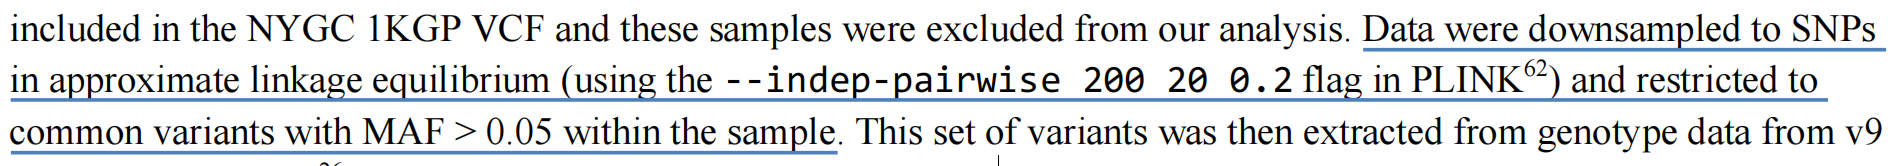

In [ ]:
%%bash
#MAGE
dir=12_Phenotype/01_PC
rm -rf ${dir}
mkdir -p ${dir}
plink --maf 0.05 --indep-pairwise 200 20 0.2 --bfile 07_sindel/sindel_final_SNP --out ${dir}/SNP_ld --keep-allele-order
plink --bfile 07_sindel/sindel_final_SNP --extract ${dir}/SNP_ld.prune.in --make-bed --out ${dir}/SNP_PC --keep-allele-order
plink --bfile ${dir}/SNP_PC --pca 10 --out ${dir}/cov

# 2. rSV calling and QC

## 2.1 LAV processing

### 2.1.1 Merge, sort, and run the rSV pipeline

In [ ]:
%%bash
# Merge, sort, and compress in one step.
# -a: allow overlaps; required because SVs and indels may share positions.
# -Oz: output compressed VCF.
bcftools concat -a 05_rSV/indel_QCed.vcf.gz 05_rSV/SV_QCed.vcf.gz \
  | bcftools sort -Oz -o 05_rSV/InDel_QCed.vcf.gz

# 3. Index the final VCF.
bcftools index -t 05_rSV/InDel_QCed.vcf.gz

In [ ]:
%%bash
mkdir -p 05_rSV/03_InDel
SVrefiner run-all --vcf 05_rSV/InDel_QCed.vcf.gz --out 05_rSV/03_InDel/02_run-all --ref chm13v2.0_chr1_22_renamed.fasta \
    --tr-vcf 06_TRCompDB/TRCompDB.oriMotifs.T2T-CHM13.vcf --threads 20
# Run this step through sbatch.

### 2.1.2 rLAV QC

1. Apply MAF ≥ 0.01 and missingness ≤ 0.2 filters to generate `rLAV.QC.vcf` from `rSV.vcf`.

In [ ]:
%%bash
# Step 1: compute updated MAF and missingness (F_MISSING), then stream uncompressed output (-Ou) to the next step.
# Step 2: use -i to retain sites with MAF >= 0.01 and missingness <= 0.2.
# Step 3: write compressed VCF output (-Oz).

bcftools +fill-tags 05_rSV/03_InDel/02_run-all/rSV.vcf.gz -Ou -- -t AF,MAF,F_MISSING | \
bcftools view -i 'MAF >= 0.01 && F_MISSING <= 0.2' -Oz -o 05_rSV/03_InDel/02_run-all/rLAV.QC.vcf.gz

# Index the filtered VCF; downstream eQTL tools usually require an index.
tabix -p vcf 05_rSV/03_InDel/02_run-all/rLAV.QC.vcf.gz

In [ ]:
%%bash
# Count variants before QC.
bcftools view -H 05_rSV/03_InDel/02_run-all/rSV.vcf.gz | wc -l

# Count variants after QC.
bcftools view -H 05_rSV/03_InDel/02_run-all/rLAV.QC.vcf.gz | wc -l

### 2.1.3 Call rLAVs from `LAV_STR_masked.vcf.gz`

In [ ]:
%%bash
lavrefiner run-all --vcf 05_rSV/LAV_STR_masked.vcf.gz \
    --out 05_rSV/05_LAV_STR_masked \
    --tr-vcf 06_TRCompDB/TRCompDB.oriMotifs.T2T-CHM13.vcf \
    --ref chm13v2.0_chr1_22_renamed.fasta \
    --threads 20
# sbatch run
# new：
lavrefiner run-all --vcf 05_rSV/LAV_STR_masked.vcf.gz \
    --out 05_rSV/05_LAV_STR_masked_new \
    --tr-vcf 06_TRCompDB/TRCompDB.oriMotifs.T2T-CHM13.vcf \
    --ref chm13v2.0_chr1_22_renamed.fasta \
    --threads 20

In [ ]:
%%bash
# Step 1: compute updated MAF and missingness (F_MISSING), then stream uncompressed output (-Ou) to the next step.
# Step 2: use -i to retain sites with MAF >= 0.01 and missingness <= 0.2.
# Step 3: write compressed VCF output (-Oz).

bcftools +fill-tags 05_rSV/05_LAV_STR_masked/rLAV.vcf -Ou -- -t AF,MAF,F_MISSING | \
bcftools view -i 'MAF >= 0.01 && F_MISSING <= 0.2' -Oz -o 05_rSV/05_LAV_STR_masked/rLAV.QC.vcf.gz

# Index the filtered VCF; downstream eQTL tools usually require an index.
tabix -p vcf 05_rSV/05_LAV_STR_masked/rLAV.QC.vcf.gz

In [ ]:
%%bash
# Count variants before QC.
bcftools view -H 05_rSV/05_LAV_STR_masked/rLAV.vcf | wc -l

# Count variants after QC.
bcftools view -H 05_rSV/05_LAV_STR_masked/rLAV.QC.vcf.gz | wc -l

In [ ]:
%%bash
lavrefiner QC --vcf 05_rSV/05_LAV_STR_masked/rLAV.QC.vcf.gz \
    --out 05_rSV/05_LAV_STR_masked \
    --tr-vcf 06_TRCompDB/TRCompDB.oriMotifs.T2T-CHM13.vcf \
    --exclude VNTR \
    --prefix rLAV_VNTR_excluded

# 3. rLAV summary statistics

## 3.1 MAF distribution

In [ ]:
%%bash
# Note: MAF is calculated only for non-TR variants here; TR-region allele-frequency estimation requires separate handling.
# Create a shared output directory.
mkdir -p 18_rLAV_stat_plot/freq_data

# Compute oLAV allele frequencies.
plink2 --vcf 16_cis_eQTL/01_Non-TR/oLAV.QC.vcf \
       --freq \
       --out 18_rLAV_stat_plot/freq_data/oLAV

# Compute rLAV allele frequencies.
plink2 --vcf 16_cis_eQTL/01_Non-TR/rLAV.QC.vcf.gz \
       --freq \
       --out 18_rLAV_stat_plot/freq_data/rLAV

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# ================= Path configuration =================
FREQ_OLAV = "18_rLAV_stat_plot/freq_data/oLAV.afreq"
FREQ_RLAV = "18_rLAV_stat_plot/freq_data/rLAV.afreq"
OUT_DIR = "18_rLAV_stat_plot"
FONT_PATH = "/home/s3020226030/arial.ttf"

# ================= Plotting configuration =================
my_font = fm.FontProperties(fname=FONT_PATH, size=8)

plt.rcParams.update({
    'font.size': 8,
    'axes.titlesize': 8,
    'axes.labelsize': 8,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'lines.linewidth': 1.0,
    'axes.linewidth': 0.8,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'pdf.fonttype': 42,
    'ps.fonttype': 42
})

# ================= Function: read allele frequency and compute MAF =================
def load_and_calc_maf(freq_file, label_name):
    if not os.path.exists(freq_file):
        print(f"Warning: file not found: {freq_file}")
        return pd.DataFrame()
        
    df = pd.read_csv(freq_file, sep='\t')
    df['ALT_FREQS'] = pd.to_numeric(df['ALT_FREQS'], errors='coerce')
    df = df.dropna(subset=['ALT_FREQS'])
    
    # Compute MAF.
    df['MAF'] = np.minimum(df['ALT_FREQS'], 1.0 - df['ALT_FREQS'])
    
    # Remove monomorphic variants (MAF = 0) and retain polymorphic sites only.
    df = df[df['MAF'] > 0].copy()
    
    df['Type'] = label_name
    return df[['MAF', 'Type']]

# ================= Extract data =================
print("Reading PLINK2 frequency files...")
df_olav = load_and_calc_maf(FREQ_OLAV, "oLAV")
df_rlav = load_and_calc_maf(FREQ_RLAV, "rLAV")

df_plot = pd.concat([df_olav, df_rlav], ignore_index=True)

# ================= Plotting =================
# Slightly widen the figure so that multiple bins are easier to read.
fig, ax = plt.subplots(figsize=(4.5, 3.0))

# Use histplot to draw grouped bars (multiple="dodge").
# binwidth=0.01 means each bar covers a 0.01 MAF interval.
sns.histplot(
    data=df_plot, 
    x="MAF", 
    hue="Type", 
    multiple="dodge",  # Display bars side by side.
    binwidth=0.01,     # Set bin width to 0.01.
    binrange=(0, 0.5), # Force the range from 0 to 0.5.
    palette={"oLAV": "#4C72B0", "rLAV": "#C44E52"}, 
    alpha=0.8,
    edgecolor="black", # Add a thin black edge to improve readability.
    linewidth=0.3,
    ax=ax
)

# Add a vertical reference line at MAF = 0.01.
ax.axvline(x=0.01, color='black', linestyle='--', linewidth=0.8, zorder=5)
# Add a small label next to the reference line.
ax.text(0.015, ax.get_ylim()[1]*0.9, 'MAF = 0.01', 
        fontproperties=my_font, color='black', va='top')

# Set labels and fonts.
ax.set_xlabel("Minor Allele Frequency (MAF)", fontproperties=my_font)
ax.set_ylabel("Count", fontproperties=my_font)
ax.set_title("MAF Histogram (Non-TR Regions, bin=0.01)", fontproperties=my_font)

ax.set_xlim(0, 0.5)

# Update tick-label fonts.
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontproperties(my_font)

# Update legend fonts.
legend = ax.get_legend()
if legend:
    plt.setp(legend.get_texts(), fontproperties=my_font)
    plt.setp(legend.get_title(), fontproperties=my_font)

# Refine axis spines.
sns.despine()
plt.tight_layout()

output_pdf = os.path.join(OUT_DIR, "MAF_histogram_NonTR.pdf")
plt.savefig(output_pdf, format='pdf', bbox_inches='tight')
print(f"Multi-bin bar plot saved to: {output_pdf}")

## 3.2 LD analysis

### 3.2.1 Merge PLINK binary files and compute targeted LD

In [ ]:
%%bash
bfile_dir="/home/s3020226030/1_rSV/01_human_chm13/25_hsq_real_data/bfile"
plink --bfile ${bfile_dir}/rLAV_STR --bmerge ${bfile_dir}/rLAV_VNTR --keep-allele-order --make-bed --out ${bfile_dir}/rLAV_TR
plink --bfile ${bfile_dir}/rLAV_TR --bmerge ${bfile_dir}/rLAV_nonTR --keep-allele-order --make-bed --out ${bfile_dir}/rLAV_all


In [ ]:
%%bash
bfile_dir="/home/s3020226030/1_rSV/01_human_chm13/25_hsq_real_data/bfile"
plink --bfile ${bfile_dir}/oLAV_STR_matched --bmerge ${bfile_dir}/oLAV_VNTR_matched --keep-allele-order --make-bed --out ${bfile_dir}/oLAV_TR_matched
plink --bfile ${bfile_dir}/oLAV_TR_matched --bmerge ${bfile_dir}/oLAV_nonTR_matched --keep-allele-order --make-bed --out ${bfile_dir}/oLAV_all


In [ ]:
%%bash
# === 1. Define input and output paths ===
bfile_snp="16_cis_eQTL/05_Non-TR_HPs_SNP/plink_tmp/SNP"
bfile_lav="25_hsq_real_data/bfile/oLAV_all"
bfile_rlav="25_hsq_real_data/bfile/rLAV_all"
out_dir="26_LD"

mkdir -p ${out_dir}

# === 2. Merge the three PLINK binary datasets ===
plink --bfile ${bfile_snp} \
    --bmerge ${bfile_lav} \
    --keep-allele-order \
    --make-bed --out ${out_dir}/temp_merge

plink --bfile ${out_dir}/temp_merge \
    --bmerge ${bfile_rlav} \
    --keep-allele-order \
    --make-bed --out ${out_dir}/all_merged

# === 3. Extract target variant IDs to improve speed ===
# Extract all LAV IDs starting with SV_ or indel_ and all rLAV IDs starting with Group_ into target_sv.txt.
awk '{if($2 ~ /^SV_/ || $2 ~ /^indel_/ || $2 ~ /^Group_/) print $2}' ${out_dir}/all_merged.bim > ${out_dir}/target_sv.txt

# === 4. Compute targeted LD ===
# Use --ld-snp-list to compute only LD pairs containing at least one target variant, avoiding exhaustive SNP-vs-SNP calculations.
threads=20
mem=80000 

plink --bfile ${out_dir}/all_merged \
    --r2 \
    --ld-snp-list ${out_dir}/target_sv.txt \
    --ld-window 999999 \
    --ld-window-kb 50 \
    --ld-window-r2 0 \
    --threads ${threads} \
    --memory ${mem} \
    --out ${out_dir}/target_ld

# Replace repeated spaces with tabs and remove possible leading tabs from PLINK output to facilitate Polars parsing.
cat ${out_dir}/target_ld.ld | tr -s ' ' '\t' | sed 's/^\t//' > ${out_dir}/target_ld.tsv

### 3.2.2 Summarize maximum r² pairs

In [ ]:
import pandas as pd
import polars as pl
import numpy as np
from tqdm import tqdm
import os
import sys

# === 1. File paths ===
input_file = "26_LD/target_ld.tsv"
out_dir = "26_LD"
os.makedirs(out_dir, exist_ok=True)

print("Initializing processing task...", flush=True)

# Get file size to estimate progress.
file_size_gb = os.path.getsize(input_file) / (1024**3)
print(f"Detected file size: {file_size_gb:.2f} GB", flush=True)

# Read 10 million rows per chunk; for three columns this is memory-safe in typical environments.
chunk_size = 10_000_000 
# Estimate the number of chunks from file size; this format is usually about 15–18 million rows per GB.
estimated_chunks = int((file_size_gb * 16_000_000) / chunk_size)

# === 2. Iterative chunked reading and processing ===
# Load only the required columns to reduce I/O and memory usage.
df_iterator = pd.read_csv(
    input_file, 
    sep="\t", 
    usecols=["SNP_A", "SNP_B", "R2"], 
    chunksize=chunk_size,
    engine="c"
)

rlav_snp_chunks = []
rlav_lav_chunks = []

print("Scanning chunks and extracting maximum LD values...", flush=True)

for chunk in tqdm(df_iterator, total=estimated_chunks, desc="Processing chunks", unit="chunk"):
    # Convert to Polars for faster processing.
    df_pl = pl.from_pandas(chunk)
    
    # Build filter masks.
    is_rlav_A = pl.col("SNP_A").str.starts_with("Group_")
    is_rlav_B = pl.col("SNP_B").str.starts_with("Group_")
    
    is_lav_A = pl.col("SNP_A").str.starts_with("SV_") | pl.col("SNP_A").str.starts_with("indel_")
    is_lav_B = pl.col("SNP_B").str.starts_with("SV_") | pl.col("SNP_B").str.starts_with("indel_")
    
    is_snp_A = pl.col("SNP_A").str.starts_with("SNP_")
    is_snp_B = pl.col("SNP_B").str.starts_with("SNP_")
    
    # --- Extract rLAV vs SNP pairs ---
    mask_rs = (is_rlav_A & is_snp_B) | (is_rlav_B & is_snp_A)
    df_rs = df_pl.filter(mask_rs)
    if df_rs.height > 0:
        # Store the rLAV ID in a single column.
        df_rs = df_rs.with_columns(
            pl.when(pl.col("SNP_A").str.starts_with("Group_"))
              .then(pl.col("SNP_A"))
              .otherwise(pl.col("SNP_B"))
              .alias("rLAV")
        )
        # Local maximum R2 within this chunk.
        agg_rs = df_rs.group_by("rLAV").agg(pl.col("R2").max().alias("max_R2"))
        rlav_snp_chunks.append(agg_rs)
        
    # --- Extract rLAV vs LAV pairs ---
    mask_rl = (is_rlav_A & is_lav_B) | (is_rlav_B & is_lav_A)
    df_rl = df_pl.filter(mask_rl)
    if df_rl.height > 0:
        df_rl = df_rl.with_columns(
            pl.when(pl.col("SNP_A").str.starts_with("Group_"))
              .then(pl.col("SNP_A"))
              .otherwise(pl.col("SNP_B"))
              .alias("rLAV")
        )
        # Local maximum R2 within this chunk.
        agg_rl = df_rl.group_by("rLAV").agg(pl.col("R2").max().alias("max_R2"))
        rlav_lav_chunks.append(agg_rl)

print("\nChunked scanning complete. Merging global results...", flush=True)

# === 3. Global aggregation ===
# Merge all local maximum R2 values and recompute global maxima.
final_rs = pl.concat(rlav_snp_chunks).group_by("rLAV").agg(pl.col("max_R2").max())
final_rl = pl.concat(rlav_lav_chunks).group_by("rLAV").agg(pl.col("max_R2").max())

# === 4. Remove redundant variants with R2 = 1.0 ===
print("Removing rLAV-vs-LAV sites with R2 = 1.0...", flush=True)

# Identify rLAV IDs with perfect R2.
r1_ids = final_rl.filter(pl.col("max_R2") == 1.0)["rLAV"].to_list()

# Apply filtering.
clean_rs = final_rs.filter(~pl.col("rLAV").is_in(r1_ids))
clean_rl = final_rl.filter(~pl.col("rLAV").is_in(r1_ids))

print(f"Removed {len(r1_ids)} perfectly co-segregating rLAV variants.", flush=True)

# Save the cleaned maximum-R2 table for downstream analyses.
clean_rs.write_csv(f"{out_dir}/Max_rLAV_vs_SNP_cleaned.tsv", separator="\t")
clean_rl.write_csv(f"{out_dir}/Max_rLAV_vs_oLAV_cleaned.tsv", separator="\t")

# === 5. Summarize frequencies across 100 bins and write the plotting TSV ===
print("Summarizing frequency-bin distributions...", flush=True)

def generate_plot_tsv(pl_df, out_path):
    r2_values = pl_df["max_R2"].drop_nulls().to_numpy()
    bins = np.linspace(0, 1, 101)
    counts, _ = np.histogram(r2_values, bins=bins)
    
    # Compute percentage frequencies.
    freq_percent = counts / counts.sum() * 100
    
    res_df = pd.DataFrame({
        "r2_bin_start": bins[:-1],
        "r2_bin_end": bins[1:],
        "frequency_percent": freq_percent
    })
    res_df.to_csv(out_path, sep="\t", index=False)

generate_plot_tsv(clean_rs, f"{out_dir}/PlotData_rLAV_vs_SNP_100bins.tsv")
generate_plot_tsv(clean_rl, f"{out_dir}/PlotData_rLAV_vs_oLAV_100bins.tsv")

print("All processing completed. Plotting files have been generated:")
print(f"  - {out_dir}/PlotData_rLAV_vs_SNP_100bins.tsv")
print(f"  - {out_dir}/PlotData_rLAV_vs_oLAV_100bins.tsv", flush=True)

### 3.2.3 Frequency distribution across 100 bins

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib import font_manager
import matplotlib

# === 1. Register and set Arial font ===
font_path = "/home/s3020226030/arial.ttf"
try:
    font_manager.fontManager.addfont(font_path)
    font_name = font_manager.FontProperties(fname=font_path).get_name()
    matplotlib.rcParams['font.family'] = font_name
    print(f"Font successfully set to: {font_name}")
except Exception as e:
    print(f"Font warning: {font_path} was not found; using the system default font.")

# === 2. Read data ===
dir_path = "26_LD"
# Ensure these files exist in the execution environment.
df_rs = pd.read_csv(f"{dir_path}/PlotData_rLAV_vs_SNP_100bins.tsv", sep="\t")
df_rl = pd.read_csv(f"{dir_path}/PlotData_rLAV_vs_oLAV_100bins.tsv", sep="\t")

# Compute bin centers.
r2_mid = (df_rs["r2_bin_start"] + df_rs["r2_bin_end"]) / 2

# Extract frequencies.
freq_rs = df_rs["frequency_percent"]
freq_rl = df_rl["frequency_percent"]

# === 3. Compute and print the percentage with R² < 0.8 ===
mask_lt_08 = r2_mid < 0.8
percent_rs_lt_08 = freq_rs[mask_lt_08].sum()
percent_rl_lt_08 = freq_rl[mask_lt_08].sum()

print("-" * 40)
print(f"Percentage of rLAV vs SNP pairs with R² < 0.8: {percent_rs_lt_08:.2f}%")
print(f"Percentage of rLAV vs LAV pairs with R² < 0.8: {percent_rl_lt_08:.2f}%")
print("-" * 40)

# === 4. Plotting ===
plt.figure(figsize=(9, 7), dpi=600)

# Publication-oriented color palette.
color_rs = '#3C5488' # Deep blue.
color_rl = '#E64B35' # Brick red.
alpha_val = 0.65     # Use slightly higher opacity for stronger visual contrast.

# Draw bar plots.
plt.bar(r2_mid, freq_rs, width=0.009, color=color_rs,
        edgecolor=None, label="rLAV versus SNP", alpha=alpha_val)
plt.bar(r2_mid, freq_rl, width=0.009, color=color_rl,
        edgecolor=None, label="rLAV versus oLAV", alpha=alpha_val)

# Add a reference line at R² = 0.8.
plt.axvline(0.8, linestyle='--', color='#555555', linewidth=1.5)

# === 5. Axis and style settings ===
plt.xlabel("$R^2$ (human)", fontsize=35)
plt.ylabel("Frequency (%)", fontsize=35)
plt.xlim(0, 1)

# Get current axes.
ax = plt.gca()

# Hide the top and right spines.
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Use thicker bottom and left spines for a cleaner publication-style plot.
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)

# Increase tick width and length for readability.
ax.tick_params(axis='x', labelsize=30, width=1.5, length=6)
ax.tick_params(axis='y', labelsize=30, width=1.5, length=6)
plt.xticks([0.2, 0.4, 0.6, 0.8, 1.0])

# Set legend.
plt.legend(fontsize=26, frameon=False, loc='upper left')

plt.tight_layout()

# === 6. Save figure ===
#os.makedirs("plot", exist_ok=True) # Ensure the output directory exists.
save_path = "20_plot/LD_rLAV.png"
plt.savefig(save_path, dpi=600, transparent=False, bbox_inches='tight') # Use bbox_inches to avoid clipping labels.
print(f"Figure saved to: {save_path}")

plt.show()

## 3.3 Overview plots

- STR, VNTR, and non-TR comparisons
  - Group-level overlapping count
  - LAV length distribution
  - Overlap rate
  - Average variant length
  - LD distribution

In [ ]:
import os
import pandas as pd
from tqdm import tqdm

# === 1. Path configuration ===
traceback_files = {
    "VNTR": "/home/s3020226030/1_rSV/01_human_chm13/05_rSV/05_LAV_STR_masked/rLAV_to_oLAV_traceback_STR_excluded_VNTR.tsv",
    "nonTR": "/home/s3020226030/1_rSV/01_human_chm13/05_rSV/05_LAV_STR_masked/rLAV_to_oLAV_traceback_STR_excluded_nonTR.tsv",
    "STR": "/home/s3020226030/1_rSV/01_human_chm13/05_rSV/03_InDel/rLAV_to_oLAV_traceback_STR.tsv"
}

matrix_dirs = {
    "VNTR": "/home/s3020226030/1_rSV/01_human_chm13/05_rSV/05_LAV_STR_masked/matrix_results/",
    "nonTR": "/home/s3020226030/1_rSV/01_human_chm13/05_rSV/05_LAV_STR_masked/matrix_results/",
    "STR": "/home/s3020226030/1_rSV/01_human_chm13/05_rSV/03_InDel/02_run-all/matrix_results/"
}

output_dir = "25_LD"
os.makedirs(output_dir, exist_ok=True)

# === 2. Efficient line-counting function ===
def get_csv_row_count(file_path):
    """
    Efficiently count lines in a CSV file, subtracting one header line by default.
    """
    if not os.path.exists(file_path):
        return None
    
    with open(file_path, 'rb') as f:
        count = sum(1 for line in f)
        
    return max(0, count - 1) if count > 0 else 0

# === 3. Main processing loop ===
all_results = []

for region, tsv_path in traceback_files.items():
    print(f"Processing data for the {region} region...")
    
    if not os.path.exists(tsv_path):
        print(f"Warning: traceback file for {region} not found: {tsv_path}. Skipping this region.")
        continue
        
    df_traceback = pd.read_csv(tsv_path, sep="\t")
    
    if "rLAV_ID" not in df_traceback.columns:
        print(f"Error: the {region} file does not contain the 'rLAV_ID' column.")
        continue
        
    # Key step 1: use split("_") and join to safely extract the Group ID.
    # Example: Group_1_17_626315_rLAV1 -> split into parts -> remove the final segment -> join back together.
    group_ids = df_traceback["rLAV_ID"].dropna().apply(lambda x: "_".join(str(x).split("_")[:-1]))
    
    # Deduplicate Group IDs so each matrix file is read only once.
    unique_group_ids = group_ids.unique()
    
    matrix_dir = matrix_dirs[region]
    region_counts = []
    missing_files = 0
    
    for group_id in tqdm(unique_group_ids, desc=f"Scanning {region} matrix files"):
        matrix_file_name = f"{group_id}_D_matrix.csv"
        matrix_file_path = os.path.join(matrix_dir, matrix_file_name)
        
        count = get_csv_row_count(matrix_file_path)
        
        if count is None:
            missing_files += 1
            count = 0  
            
        # Key step 2: retain only Group_ID and Count.
        region_counts.append({
            "Group_ID": group_id,
            "Count": count
        })
        
    if missing_files > 0:
        print(f"Note: {missing_files} matrix files were not found for {region}.")
        
    # Convert to DataFrame.
    df_counts = pd.DataFrame(region_counts)
    
    # Save region-specific results.
    region_out_path = f"{output_dir}/Group_Count_Only_{region}.tsv"
    df_counts.to_csv(region_out_path, sep="\t", index=False)
    print(f"{region} summary saved to: {region_out_path}\n")
    
    all_results.append(df_counts)

# === 4. Global summary ===
if all_results:
    print("Merging global results...")
    df_final = pd.concat(all_results, ignore_index=True)
    
    # Deduplicate across regions; this has no effect if Group_IDs do not overlap between regions.
    df_final = df_final.drop_duplicates(subset=["Group_ID"])
    
    final_out_path = f"{output_dir}/All_Regions_Group_Count.tsv"
    df_final.to_csv(final_out_path, sep="\t", index=False)
    print(f"All region summaries completed. Final summary table generated: {final_out_path}")
else:
    print("No region-level data were successfully processed.")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np

def plot_osv_freq_distribution(region_file_dict, cap_value=13):
    """
    Plot the oSV count distribution across regions using publication-oriented styling.
    - X-axis starts from 2.
    - Tail counts are collapsed into "13+".
    - Colors and positions are ordered as STR, VNTR, and non-TR.
    """
    
    # === 1. Color and position configuration ===
    # Assign STR to red and non-TR to green.
    region_colors = {
        "STR": "#E64B35",     # Brick red.
        "VNTR": "#3C5488",    # Deep blue.
        "non-TR": "#00A087"   # Teal green.
    }
    
    # Specify plotting order explicitly: STR on the left and non-TR on the right.
    plot_order = ["STR", "VNTR", "non-TR"]

    region_freqs = {}
    
    # Generate a continuous X-axis list: [2, 3, ..., 13].
    all_x_ticks = list(range(2, cap_value + 1))
    
    # === 2. Read and process data ===
    for region in plot_order:
        file_path = region_file_dict.get(region)
        if not file_path or not os.path.exists(file_path):
            print(f"File not found: {file_path}. Skipping {region}.")
            continue
            
        df = pd.read_csv(file_path, sep="\t")
        
        if "Count" in df.columns:
            counts = df["Count"].dropna().astype(int)
            
            # Key step: remove values < 2 because the plot starts from 2.
            counts = counts[counts >= 2]
            
            # Collapse all values >= 13 to 13.
            counts_capped = counts.apply(lambda x: x if x < cap_value else cap_value)
            
            freq_series = counts_capped.value_counts().to_dict()
            region_freqs[region] = freq_series
        else:
            print(f"The 'Count' column was not found in {file_path}. Please check the file format.")

    if not region_freqs:
        print("No data were successfully read.")
        return

    # === 3. Plotting ===
    plt.figure(figsize=(14, 8), dpi=600)
    
    x = np.arange(len(all_x_ticks))
    valid_regions = [r for r in plot_order if r in region_freqs]
    total_bars = len(valid_regions)
    bar_width = 0.8 / total_bars if total_bars > 0 else 0.8

    # Draw grouped bar plots.
    for i, region in enumerate(valid_regions):
        freq_map = region_freqs[region]
        color = region_colors.get(region, f"C{i}")
        
        # Retrieve frequencies in continuous order from 2 to 13.
        y_values = [freq_map.get(val, 0) for val in all_x_ticks]
        offset = (i - total_bars / 2) * bar_width + bar_width / 2
        
        plt.bar(x + offset, y_values, width=bar_width, 
                label=region, color=color, alpha=0.85, log=True)

    # === 4. Axis and style settings ===
    plt.xlabel("Overlapping LAVs per cluster", fontsize=32)
    plt.ylabel("Count (log scale)", fontsize=32)
    
    # Generate X-axis labels: "2", "3", ..., "12", "13+".
    x_labels = [str(val) for val in range(2, cap_value)] + [f"{cap_value}+"]
    
    plt.xticks(ticks=x, labels=x_labels, fontsize=24, rotation=0)
    plt.yticks(fontsize=26)
    
    # Grid lines.
    plt.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)

    # Thicken spines and hide the top/right spines.
    ax = plt.gca()
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.spines['left'].set_linewidth(1.5)
    ax.tick_params(axis='x', width=1.5, length=7)
    ax.tick_params(axis='y', width=1.5, length=7)

    # Legend settings.
    plt.legend(fontsize=28, frameon=False)

    plt.tight_layout()
    
    # === 5. Save output ===
    os.makedirs("plot", exist_ok=True)
    save_path = "plot/oSV_per_group_regions_13plus.pdf"
    plt.savefig(save_path, dpi=600, transparent=False, bbox_inches='tight')
    print(f"Figure saved to: {save_path}")
    
    plt.show()

# === 6. Run plotting function ===
# The dictionary order does not matter because plot_order above fixes the plotting order.
input_files = {
    "non-TR": "25_LD/Group_Count_Only_nonTR.tsv",
    "VNTR": "25_LD/Group_Count_Only_VNTR.tsv",
    "STR": "25_LD/Group_Count_Only_STR.tsv"
}

plot_osv_freq_distribution(input_files, cap_value=13)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import matplotlib.ticker as ticker

# === 1. File paths and color palette ===
base_dir = "/home/s3020226030/1_rSV/01_human_chm13/25_hsq_real_data/bfile/"

bim_files = {
    "STR": {"oLAV": "oLAV_STR_matched.bim", "rLAV": "rLAV_STR.bim"},
    "VNTR": {"oLAV": "oLAV_VNTR_matched.bim", "rLAV": "rLAV_VNTR.bim"},
    "non-TR": {"oLAV": "oLAV_nonTR_matched.bim", "rLAV": "rLAV_nonTR.bim"}
}

region_colors = {
    "STR": "#E64B35",     # Red.
    "VNTR": "#3C5488",    # Deep blue.
    "non-TR": "#00A087"   # Teal green.
}

# === 2. Read oLAV and rLAV data separately ===
data_olav = {r: [] for r in bim_files}
data_rlav = {r: [] for r in bim_files}
all_deltas = []

print("Reading BIM files and merging data...")
for region, files in bim_files.items():
    for lav_type, filename in files.items():
        path = os.path.join(base_dir, filename)
        
        if not os.path.exists(path) and lav_type == "rLAV":
            path = os.path.join(base_dir, f"rLAV_{region.replace('-', '')}_matched.bim")
            
        if not os.path.exists(path):
            continue
            
        df = pd.read_csv(path, sep=r'\s+', header=None, usecols=[4, 5])
        df = df.dropna().astype(str)
        
        delta = df[4].str.len() - df[5].str.len()
        delta = delta[delta != 0].values
        
        if lav_type == "oLAV":
            data_olav[region] = delta
        else:
            data_rlav[region] = delta
            
        all_deltas.extend(delta)

if not all_deltas:
    raise ValueError("No valid data were read.")

# === 3. Generate shared global bins ===
max_abs_len = max(abs(min(all_deltas)), abs(max(all_deltas)))
min_abs_len = max(1, np.min(np.abs(all_deltas))) 

threshold = 100 

if max_abs_len > threshold:
    lin_bins = np.linspace(min_abs_len, threshold, 12)
    log_bins = np.geomspace(threshold, max_abs_len, 40)[1:] 
    pos_bins = np.concatenate([lin_bins, log_bins])
else:
    pos_bins = np.linspace(min_abs_len, max_abs_len, 30)

neg_bins = -pos_bins[::-1]
bins = np.concatenate([neg_bins, pos_bins])

# === 4. Build mirrored two-panel canvas ===
fig, (ax_top, ax_bot) = plt.subplots(nrows=2, ncols=1, figsize=(15, 12), dpi=600, 
                                     sharex=True, gridspec_kw={'hspace': 0.0})

regions = ["STR", "VNTR", "non-TR"]

# Plot upper panel: oLAV with mean-length calculation.
for r in regions:
    # Compute mean absolute length difference.
    mean_bp = np.mean(np.abs(data_olav[r])) if len(data_olav[r]) > 0 else 0
    # Rebuild labels with mean length.
    label_text = f"{r} (Mean: {int(mean_bp):,} bp)"
    
    ax_top.hist(data_olav[r], bins=bins, color=region_colors[r], label=label_text, 
                edgecolor='white', linewidth=0.3, alpha=0.6, log=True)

# Plot lower panel: rLAV with mean-length calculation.
for r in regions:
    mean_bp = np.mean(np.abs(data_rlav[r])) if len(data_rlav[r]) > 0 else 0
    label_text = f"{r} (Mean: {int(mean_bp):,} bp)"
    
    ax_bot.hist(data_rlav[r], bins=bins, color=region_colors[r], label=label_text,
                edgecolor='white', linewidth=0.3, alpha=0.6, log=True)

ax_bot.invert_yaxis()

for ax in [ax_top, ax_bot]:
    ax.axvline(0, color='#222222', linestyle='-', linewidth=2, zorder=3)
    ax.axvline(-50, color='#888888', linestyle='--', linewidth=1.5, zorder=3)
    ax.axvline(50, color='#888888', linestyle='--', linewidth=1.5, zorder=3)

# === 5. Axis scaling and harmonization ===
for ax in [ax_top, ax_bot]:
    ax.set_xscale('symlog', linthresh=threshold if max_abs_len > threshold else max_abs_len, linscale=0.4)
    ax.set_ylim(bottom=0.5) 

ymax = max(ax_top.get_ylim()[1], ax_bot.get_ylim()[0]) 
ax_top.set_ylim(0.5, ymax * 1.5) 
ax_bot.set_ylim(ymax * 1.5, 0.5) 

# === 6. Labels and ticks ===
ax_top.set_ylabel("oLAV Count (log scale)", fontsize=32, labelpad=15)
ax_bot.set_ylabel("rLAV Count (log scale)", fontsize=32, labelpad=15)
plt.xlabel("Variant Length (bp)", fontsize=35, labelpad=15)

x_ticks = [-10000, -1000, -100, 0, 100, 1000, 10000]
x_ticks = [t for t in x_ticks if -max_abs_len <= t <= max_abs_len]
if 0 not in x_ticks: x_ticks.append(0)
x_ticks.sort()
ax_bot.set_xticks(x_ticks)

def format_symlog(x, pos):
    if x == 0: return "0"
    elif x > 0: return f"+{int(x)}"
    else: return f"{int(x)}"

ax_bot.xaxis.set_major_formatter(ticker.FuncFormatter(format_symlog))
plt.xticks(fontsize=28, rotation=0) 
ax_top.tick_params(axis='y', labelsize=26)
ax_bot.tick_params(axis='y', labelsize=26)

# === 7. Add annotations to the upper panel only ===
log_y_min, log_y_max = np.log10(0.5), np.log10(ymax * 1.5)

text_y_lines = 10**(log_y_min + (log_y_max - log_y_min) * 0.92)
ax_top.text(-55, text_y_lines, "-50", fontsize=24, color='#666666', fontweight='bold', ha='right', va='center')
ax_top.text(55, text_y_lines, "+50", fontsize=24, color='#666666', fontweight='bold', ha='left', va='center')

text_y_regions = 10**(log_y_min + (log_y_max - log_y_min) * 0.83) 
ax_top.text(-500, text_y_regions, "Deletions", fontsize=30, color='#333333', fontweight='bold', ha='center')
ax_top.text(500, text_y_regions, "Insertions", fontsize=30, color='#333333', fontweight='bold', ha='center')

# === 8. Spines and center baseline ===
for ax in [ax_top, ax_bot]:
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(2)
    ax.tick_params(axis='both', which='major', direction='out', length=8, width=2, color='black')

ax_top.spines['top'].set_visible(False)
ax_top.spines['bottom'].set_visible(False) 
ax_top.tick_params(axis='x', which='both', bottom=False) 

ax_bot.spines['bottom'].set_visible(False) 
ax_bot.spines['top'].set_visible(True)     
ax_bot.spines['top'].set_linewidth(3)      
ax_bot.spines['top'].set_color('#222222')

# === 9. Separate legends for the upper and lower panels ===
# Use a slightly smaller font size to accommodate labels with mean values and avoid overlap.
ax_top.legend(fontsize=22, frameon=False, loc='upper left', bbox_to_anchor=(0.01, 0.78))
# Place the lower-panel legend in the lower-left corner.
ax_bot.legend(fontsize=22, frameon=False, loc='lower left', bbox_to_anchor=(0.01, 0.22))

plt.tight_layout()

# === 10. Save figure ===
save_path = "20_plot/rLAV_vs_oLAV_Mirrored_Hist_with_Mean.pdf"
plt.savefig(save_path, dpi=600, transparent=False, bbox_inches='tight')
print(f"Mirrored plot with mean-length labels saved to: {save_path}")

plt.show()

- Overlap rate

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.patheffects as path_effects

# === 1. Input data ===
# Data note: oLAV counts are derived from total LAV counts and overlap rates.
# STR oLAV = 355804 * 0.4684461 ≈ 166675
# VNTR oLAV = 73242 * 0.25075776 ≈ 18366
# non-TR oLAV = 642523 * 0.02908378 ≈ 18687

data = {
    "STR": {"LAV": 355804, "oLAV": 166675},
    "VNTR": {"LAV": 73242, "oLAV": 18366},
    "non-TR": {"LAV": 642523, "oLAV": 18687}
}

# === 2. Color palette consistent with the previous plot ===
region_colors = {
    "STR": "#E64B35",     # Red.
    "VNTR": "#3C5488",    # Deep blue.
    "non-TR": "#00A087"   # Teal green.
}
olav_common_color = "#F39B7F"  # Shared oLAV color: coral orange, selected for contrast with the region colors.

# === 3. Prepare plotting data ===
regions = []
olav_counts = []
non_overlap_lav_counts = []
lav_colors = []
overlap_rates = []

for region, values in data.items():
    lav = values["LAV"]
    olav = values["oLAV"]
    non_overlap_lav = lav - olav

    regions.append(region)
    olav_counts.append(olav)
    non_overlap_lav_counts.append(non_overlap_lav)
    lav_colors.append(region_colors[region])
    overlap_rates.append(olav / lav * 100)

# === 4. Main plotting step ===
fig, ax = plt.subplots(figsize=(10, 9), dpi=600)

# oLAV: bottom segment with shared color.
ax.bar(regions, olav_counts, color=olav_common_color, label="overlapping LAV", width=0.6)
# Non-overlapping LAV: top segment colored by region.
ax.bar(regions, non_overlap_lav_counts, bottom=olav_counts, color=lav_colors, width=0.6)

# === 5. Text and percentage annotations ===
# Compute visual y-axis height to place total-count labels dynamically.
max_y = max([data[r]["LAV"] for r in data])

# Total-count labels.
for i in range(len(regions)):
    total = olav_counts[i] + non_overlap_lav_counts[i]
    # Add 1% dynamic padding so labels do not overlap the bars.
    ax.text(i, total + (max_y * 0.015), f"{int(total):,}", ha='center', va='bottom', fontsize=28)

# Percentage labels inside the oLAV segment.
for i in range(len(regions)):
    o = olav_counts[i]
    rate = overlap_rates[i]
    if o > 0:
        # The non-TR oLAV segment is relatively small; move the label slightly upward if needed.
        y_pos = o / 2 if o > 20000 else o / 2 + 5000 
        
        text = ax.text(i, y_pos, f"{rate:.1f}%", ha='center', va='center', fontsize=26, color='white', fontweight='bold')
        # Add a subtle dark stroke to keep the label legible on the coral background.
        text.set_path_effects([
            path_effects.Stroke(linewidth=1.5, foreground='#333333'), 
            path_effects.Normal()
        ])

# === 6. Axes and styling ===
# Spine settings.
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(2) # Use slightly thicker spines.
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set y-axis ticks to accommodate the large non-TR count.
ax.set_yticks([0, 100000, 200000, 300000, 400000, 500000, 600000, 700000])

# Ensure visible x- and y-axis ticks.
ax.tick_params(
    axis='y', which='major', direction='out',
    length=8, width=2, color='black', left=True, right=False
)
ax.tick_params(
    axis='x', which='major', direction='out',
    length=8, width=2, color='black', bottom=True, top=False
)

# Format y-axis labels in thousands (k).
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{int(x / 1000)}k" if x >= 1000 else str(int(x))))

# Label settings.
ax.set_ylabel("LAV Count", fontsize=35)
ax.tick_params(axis='x', labelsize=32)
ax.tick_params(axis='y', labelsize=28)

# === 7. Legend settings ===
ax.legend(frameon=False, loc='upper left', fontsize=26)

# === 8. Export and display ===
plt.tight_layout()
#save_path = "oLAV_percentage_stacked.png"
#plt.savefig(save_path, dpi=600, transparent=False, bbox_inches='tight')
#print(f"Plot completed and saved to: {save_path}")

plt.show()

- SV/indel fraction

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import matplotlib.ticker as ticker

# === 1. File paths and mappings ===
base_dir = "/home/s3020226030/1_rSV/01_human_chm13/25_hsq_real_data/bfile/"

region_map = {
    "STR": "STR",
    "VNTR": "VNTR",
    "non-TR": "nonTR" 
}

# === 2. Summary categories and four-color palette ===
ordered_types = ["SV (deletion)", "indel (deletion)", "indel (insertion)", "SV (insertion)"]
colors = [
    '#3C5488',  # Deep blue. -> SV (deletion)
    '#4DBBD5',  # Light blue -> indel (deletion).
    '#F39B7F',  # Light orange -> indel (insertion).
    '#E64B35'   # Red. -> SV (insertion)
]

# === 3. Read BIM files and classify variants by length difference ===
counts_sv_del = []
counts_in_del = []
counts_in_ins = []
counts_sv_ins = []
x_pos = []     
x_labels = []  

current_x = 0
print("Reading BIM files and counting four variant-length categories...")

for region_label, file_suffix in region_map.items():
    for lav_type in ["oLAV", "rLAV"]:
        if lav_type == "oLAV":
            file_name = f"oLAV_{file_suffix}_matched.bim"
        else:
            file_name = f"rLAV_{file_suffix}.bim" 
            
        path = os.path.join(base_dir, file_name)
        if not os.path.exists(path) and lav_type == "rLAV":
            path = os.path.join(base_dir, f"rLAV_{file_suffix}_matched.bim")
            
        counts_dict = {t: 0 for t in ordered_types}
        
        if os.path.exists(path):
            df = pd.read_csv(path, sep=r'\s+', header=None, usecols=[4, 5])
            df = df.dropna().astype(str)
            
            delta = df[4].str.len() - df[5].str.len()
            delta = delta[delta != 0].values 
            
            counts_dict["SV (deletion)"] = np.sum(delta <= -50)
            counts_dict["indel (deletion)"] = np.sum((delta < 0) & (delta > -50))
            counts_dict["indel (insertion)"] = np.sum((delta > 0) & (delta < 50))
            counts_dict["SV (insertion)"] = np.sum(delta >= 50)
            
        counts_sv_del.append(counts_dict["SV (deletion)"])
        counts_in_del.append(counts_dict["indel (deletion)"])
        counts_in_ins.append(counts_dict["indel (insertion)"])
        counts_sv_ins.append(counts_dict["SV (insertion)"])
        
        x_labels.append(lav_type)
        x_pos.append(current_x)
        current_x += 1 
        
    current_x += 1 

# === 4. Draw vertical grouped bar plot for the four categories ===
fig, ax = plt.subplots(figsize=(16, 9), dpi=600)

bar_width = 0.20  

# Compute center offsets for the four bars.
pos_sv_del = [p - 1.5 * bar_width for p in x_pos]
pos_in_del = [p - 0.5 * bar_width for p in x_pos]
pos_in_ins = [p + 0.5 * bar_width for p in x_pos]
pos_sv_ins = [p + 1.5 * bar_width for p in x_pos]

# Draw bars.
ax.bar(pos_sv_del, counts_sv_del, width=bar_width, label=ordered_types[0], color=colors[0], edgecolor='white', linewidth=1.5, zorder=3)
ax.bar(pos_in_del, counts_in_del, width=bar_width, label=ordered_types[1], color=colors[1], edgecolor='white', linewidth=1.5, zorder=3)
ax.bar(pos_in_ins, counts_in_ins, width=bar_width, label=ordered_types[2], color=colors[2], edgecolor='white', linewidth=1.5, zorder=3)
ax.bar(pos_sv_ins, counts_sv_ins, width=bar_width, label=ordered_types[3], color=colors[3], edgecolor='white', linewidth=1.5, zorder=3)

# === 5. Hybrid y-axis using symlog scale ===
ax.set_yscale('symlog', linthresh=100)
ax.set_ylim(bottom=-2) 

y_ticks = [0, 100, 1000, 10000, 100000, 1000000]
ax.set_yticks(y_ticks)

def format_log(x, pos):
    if x == 0: return "0"
    elif x < 1000: return str(int(x))
    elif x < 1000000: return f"{int(x/1000)}k"
    else: return f"{x/1000000:g}M"

ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_log))
ax.set_ylabel("Count of LAVs (log scale)", fontsize=32, labelpad=15, fontweight='bold')

# === 6. X-axis and top region labels ===
ax.set_xticks(x_pos)
# Increase x-axis tick-label font size for oLAV/rLAV labels.
ax.set_xticklabels(x_labels, fontsize=30, color='#444444')

trans = ax.get_xaxis_transform()
str_center = (x_pos[0] + x_pos[1]) / 2
vntr_center = (x_pos[2] + x_pos[3]) / 2
nontr_center = (x_pos[4] + x_pos[5]) / 2

text_y = 1.02 
ax.text(str_center, text_y, 'STR', ha='center', va='bottom', transform=trans, fontsize=36, fontweight='bold', color='#111111')
ax.text(vntr_center, text_y, 'VNTR', ha='center', va='bottom', transform=trans, fontsize=36, fontweight='bold', color='#111111')
ax.text(nontr_center, text_y, 'non-TR', ha='center', va='bottom', transform=trans, fontsize=36, fontweight='bold', color='#111111')

# === 7. Axis and style settings ===
ax.tick_params(axis='x', which='major', direction='out', length=6, width=2, color='#666666', pad=8)
# Increase y-axis tick-label font size.
ax.tick_params(axis='y', which='major', direction='out', length=8, width=2.5, color='black', labelsize=30)

for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_linewidth(2.5) 

ax.yaxis.grid(True, linestyle='--', alpha=0.4, color='#CCCCCC', zorder=0)
ax.set_axisbelow(True)

# === 8. Legend settings ===
# Remove legend title and slightly increase legend font size.
ax.legend(frameon=False, loc='upper right', fontsize=28)

plt.tight_layout()

# === 9. Export figure ===
#os.makedirs("plot", exist_ok=True)
#save_path = "plot/LAV_Classification_4_Categories_Symlog.png"
#plt.savefig(save_path, dpi=600, transparent=False, bbox_inches='tight')
#print(f"Updated figure saved to: {save_path}")

plt.show()

## 3.4 Trace rLAVs back to contributing oLAVs

- STR rLAV-to-oLAV traceback

In [ ]:
import os
from collections import defaultdict
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed

# ── 1. Path configuration ───────────────────────────────────────────────────
BASE_DIR = "/home/s3020226030/1_rSV/01_human_chm13"
RLAV_BIM = f"{BASE_DIR}/25_hsq_real_data/bfile/rLAV_STR.bim"
OLAV_BIM = f"{BASE_DIR}/25_hsq_real_data/bfile/oLAV.bim"
MATRIX_DIR = f"{BASE_DIR}/05_rSV/03_InDel/02_run-all/matrix_results"

# Output file path.
OUTPUT_TSV = f"{BASE_DIR}/05_rSV/03_InDel/rLAV_to_oLAV_traceback_STR.tsv"
THREADS = 10  # Number of worker processes.

# ── 2. Core worker function ────────────────────────────────────────────────
def process_matrix(args):
    """Parse a single D-matrix and map contributing oLAV IDs using the provided contiguous slice."""
    pfx, target_r_vids, olav_slice, matrix_dir = args
    csv_path = os.path.join(matrix_dir, f"{pfx}_D_matrix.csv")
    
    results = []
    if not os.path.exists(csv_path):
        for r_vid in target_r_vids:
            results.append((r_vid, 0, "ERROR: Matrix file not found"))
        return results

    try:
        with open(csv_path, 'r', encoding='utf-8') as f:
            header_line = f.readline()
            if not header_line: return results
            
            header_parts = [col.strip() for col in header_line.split(',')]
            col_names = header_parts[1:] 
            num_cols = len(col_names)
            
            col_to_row_indices = {c: [] for c in col_names}
            
            row_idx = 0
            for line in f:
                parts = line.strip().split(',')
                for i in range(num_cols):
                    if i + 1 < len(parts) and parts[i + 1] == '1':
                        col_to_row_indices[col_names[i]].append(row_idx)
                row_idx += 1
                
        for r_vid in target_r_vids:
            col_name = r_vid.rsplit('_', 1)[1]
            
            if col_name not in col_to_row_indices:
                results.append((r_vid, 0, "ERROR: Column not found in matrix"))
                continue
                
            active_rows = col_to_row_indices[col_name]
            col_sum = len(active_rows)
            
            contributing_olavs = []
            for idx in active_rows:
                # Use matrix row order strictly so large D-matrices can still be traced accurately.
                if idx < len(olav_slice):
                    contributing_olavs.append(olav_slice[idx])
                else:
                    contributing_olavs.append(f"OUT_OF_BOUNDS_{idx}")
            
            olav_str = ",".join(contributing_olavs) if contributing_olavs else "NONE"
            results.append((r_vid, col_sum, olav_str))
            
        return results
        
    except Exception as e:
        for r_vid in target_r_vids:
            results.append((r_vid, 0, f"ERROR: {str(e)}"))
        return results

# ── 3. Main workflow ───────────────────────────────────────────────────────
def main():
    print("=" * 70)
    print("Starting precise rLAV-to-oLAV traceback based on anchor positions and row order.")
    print("=" * 70)
    
    # ── Step 1: Build the global oLAV registry and anchor index ──
    print(f"[1/4] Loading the underlying oLAV BIM file and indexing anchors: {OLAV_BIM} ...")
    all_olav_vids = []
    olav_start_idx = {} # Global row index of the first occurrence of each (chrom, pos) anchor.
    
    with open(OLAV_BIM, 'r', encoding='utf-8') as f:
        for line_idx, line in enumerate(f):
            parts = line.strip().split('\t')
            if len(parts) >= 4:
                chrom, vid, pos = parts[0], parts[1], parts[3]
                all_olav_vids.append(vid)
                
                # Record only the first row index for each anchor.
                key = (chrom, pos)
                if key not in olav_start_idx:
                    olav_start_idx[key] = line_idx
                    
    print(f"Indexed {len(all_olav_vids):,} underlying oLAV records.")

    # ── Step 2: Parse the rLAV table and record the original order ──
    print(f"[2/4] Loading target rLAVs and recording the original order: {RLAV_BIM} ...")
    tasks_by_pfx = defaultdict(list)
    r_vid_order = {}  # Original row order of each rLAV.
    
    with open(RLAV_BIM, 'r', encoding='utf-8') as f:
        for line_idx, line in enumerate(f):
            parts = line.strip().split('\t')
            if len(parts) >= 2:
                r_vid = parts[1]
                pfx = r_vid.rsplit('_', 1)[0]
                
                tasks_by_pfx[pfx].append(r_vid)
                r_vid_order[r_vid] = line_idx
                
    print(f"Loaded {len(r_vid_order):,} target rLAVs.")

    # ── Step 3: Prepare arguments and pass corresponding oLAV slices to workers ──
    print(f"[3/4] Parsing D-matrices in parallel for traceback matching (threads={THREADS}) ...")
    task_args = []
    for pfx, r_vids in tasks_by_pfx.items():
        parts = pfx.split('_')
        if len(parts) >= 4:
            chrom_str = parts[1]
            pos_str = parts[3]
            
            # Find the start row index from the anchor dictionary.
            start_idx = olav_start_idx.get((chrom_str, pos_str))
            
            if start_idx is not None:
                # Core logic: pass a 50,000-variant slice starting at start_idx to the corresponding worker.
                # This preserves the natural BIM row order and covers the expected D-matrix row indices.
                olav_slice = all_olav_vids[start_idx : start_idx + 50000]
                task_args.append((pfx, r_vids, olav_slice, MATRIX_DIR))
            else:
                # Rare edge case: the starting coordinate is not found in the BIM file.
                task_args.append((pfx, r_vids, [], MATRIX_DIR))

    all_bom_records = []
    with ProcessPoolExecutor(max_workers=THREADS) as executor:
        futures = [executor.submit(process_matrix, arg) for arg in task_args]
        for future in tqdm(as_completed(futures), total=len(task_args), desc="Parsing Matrices", unit="grp"):
            all_bom_records.extend(future.result())

    # ── Step 4: Restore original order and write output ──
    print(f"\n[4/4] Restoring original order and writing TSV: {OUTPUT_TSV} ...")
    out_dir = os.path.dirname(OUTPUT_TSV)
    if out_dir: os.makedirs(out_dir, exist_ok=True)
    
    # Force alignment to the original row order of the source rLAV BIM file.
    all_bom_records.sort(key=lambda x: r_vid_order.get(x[0], float('inf')))
    
    with open(OUTPUT_TSV, 'w', encoding='utf-8') as f_out:
        f_out.write("rLAV_ID\tcol_sum\tContributing_oLAVs\n")
        for record in all_bom_records:
            f_out.write(f"{record[0]}\t{record[1]}\t{record[2]}\n")
            
    print("=" * 70)
    print("Traceback completed. The output is aligned to the original row order of rLAV_STR.bim.")
    print(f"Traceback table saved to: {OUTPUT_TSV}")
    print("=" * 70)

if __name__ == "__main__":
    main()

In [ ]:
import os
import pandas as pd
import numpy as np

# ── 1. Paths and configuration ──
BASE_DIR = "/home/s3020226030/1_rSV/01_human_chm13"
MAIN_DIR = f"{BASE_DIR}/25_hsq_real_data"
BFILE_DIR = f"{MAIN_DIR}/bfile"

TRACEBACK_TSV = f"{BASE_DIR}/05_rSV/03_InDel/rLAV_to_oLAV_traceback_STR.tsv" 
RLAV_BIM = f"{BFILE_DIR}/rLAV_STR.bim"

# Output file.
OUTPUT_FILE = f"{MAIN_DIR}/rLAV_STR_oLAV_list.txt"

# ── 2. Load rLAV_STR.bim ──
print("Reading rLAV_STR.bim...", flush=True)
df_rlav = pd.read_csv(RLAV_BIM, sep='\t', header=None, usecols=[1], names=['vid'])
rlav_vntr_ids = set(df_rlav['vid'].tolist())
print(f"   -> Found {len(rlav_vntr_ids)} rLAV IDs.")

# ── 3. Parse the traceback table and extract oLAV IDs ──
print("Parsing traceback table and extracting oLAV IDs...", flush=True)
df_trace = pd.read_csv(TRACEBACK_TSV, sep='\t')

olav_set = set()
match_count = 0

for _, row in df_trace.iterrows():
    r_vid = row['rLAV_ID']
    if r_vid in rlav_vntr_ids:
        match_count += 1
        olav_str = str(row['Contributing_oLAVs'])
        if olav_str != "NONE" and pd.notna(olav_str):
            pieces = [x.strip() for x in olav_str.split(',') if not x.startswith("OUT_OF_BOUNDS")]
            olav_set.update(pieces)

print(f"   -> Matched {match_count} rLAVs.")
print(f"   -> Extracted {len(olav_set)} unique oLAV IDs.")

# ── 4. Write output ──
print(f"Writing output to: {OUTPUT_FILE}", flush=True)
with open(OUTPUT_FILE, 'w') as f:
    for olav_id in sorted(olav_set):
        f.write(f"{olav_id}\n")

print("Done.")

In [ ]:
%%bash
plink --bfile /home/s3020226030/1_rSV/01_human_chm13/25_hsq_real_data/bfile/oLAV \
    --keep-allele-order --extract /home/s3020226030/1_rSV/01_human_chm13/25_hsq_real_data/rLAV_STR_oLAV_list.txt \
    --make-bed --out /home/s3020226030/1_rSV/01_human_chm13/25_hsq_real_data/bfile/oLAV_STR_matched

- STR-masked rLAV-to-oLAV traceback for VNTR and non-TR regions

In [ ]:
import os
from collections import defaultdict
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed

# ── 1. Path configuration ───────────────────────────────────────────────────
BASE_DIR = "/home/s3020226030/1_rSV/01_human_chm13"
RLAV_BIM = f"{BASE_DIR}/25_hsq_real_data/bfile/rLAV_STR_excluded.bim"
OLAV_BIM = f"{BASE_DIR}/25_hsq_real_data/bfile/oLAV_STR_excluded.bim"
MATRIX_DIR = f"{BASE_DIR}/05_rSV/05_LAV_STR_masked/matrix_results"

# Output file path.
OUTPUT_TSV = f"{BASE_DIR}/05_rSV/05_LAV_STR_masked/rLAV_to_oLAV_traceback_STR_excluded.tsv"
THREADS = 10  # Number of worker processes.

# ── 2. Core worker function ────────────────────────────────────────────────
def process_matrix(args):
    """Parse a single D-matrix and map contributing oLAV IDs using the provided contiguous slice."""
    pfx, target_r_vids, olav_slice, matrix_dir = args
    csv_path = os.path.join(matrix_dir, f"{pfx}_D_matrix.csv")
    
    results = []
    if not os.path.exists(csv_path):
        for r_vid in target_r_vids:
            results.append((r_vid, 0, "ERROR: Matrix file not found"))
        return results

    try:
        with open(csv_path, 'r', encoding='utf-8') as f:
            header_line = f.readline()
            if not header_line: return results
            
            header_parts = [col.strip() for col in header_line.split(',')]
            col_names = header_parts[1:] 
            num_cols = len(col_names)
            
            col_to_row_indices = {c: [] for c in col_names}
            
            row_idx = 0
            for line in f:
                parts = line.strip().split(',')
                for i in range(num_cols):
                    if i + 1 < len(parts) and parts[i + 1] == '1':
                        col_to_row_indices[col_names[i]].append(row_idx)
                row_idx += 1
                
        for r_vid in target_r_vids:
            col_name = r_vid.rsplit('_', 1)[1]
            
            if col_name not in col_to_row_indices:
                results.append((r_vid, 0, "ERROR: Column not found in matrix"))
                continue
                
            active_rows = col_to_row_indices[col_name]
            col_sum = len(active_rows)
            
            contributing_olavs = []
            for idx in active_rows:
                # Use matrix row order strictly so large D-matrices can still be traced accurately.
                if idx < len(olav_slice):
                    contributing_olavs.append(olav_slice[idx])
                else:
                    contributing_olavs.append(f"OUT_OF_BOUNDS_{idx}")
            
            olav_str = ",".join(contributing_olavs) if contributing_olavs else "NONE"
            results.append((r_vid, col_sum, olav_str))
            
        return results
        
    except Exception as e:
        for r_vid in target_r_vids:
            results.append((r_vid, 0, f"ERROR: {str(e)}"))
        return results

# ── 3. Main workflow ───────────────────────────────────────────────────────
def main():
    print("=" * 70)
    print("Starting precise rLAV-to-oLAV traceback based on anchor positions and row order.")
    print("=" * 70)
    
    # ── Step 1: Build the global oLAV registry and anchor index ──
    print(f"[1/4] Loading the underlying oLAV BIM file and indexing anchors: {OLAV_BIM} ...")
    all_olav_vids = []
    olav_start_idx = {} # Global row index of the first occurrence of each (chrom, pos) anchor.
    
    with open(OLAV_BIM, 'r', encoding='utf-8') as f:
        for line_idx, line in enumerate(f):
            parts = line.strip().split('\t')
            if len(parts) >= 4:
                chrom, vid, pos = parts[0], parts[1], parts[3]
                all_olav_vids.append(vid)
                
                # Record only the first row index for each anchor.
                key = (chrom, pos)
                if key not in olav_start_idx:
                    olav_start_idx[key] = line_idx
                    
    print(f"Indexed {len(all_olav_vids):,} underlying oLAV records.")

    # ── Step 2: Parse the rLAV table and record the original order ──
    print(f"[2/4] Loading target rLAVs and recording the original order: {RLAV_BIM} ...")
    tasks_by_pfx = defaultdict(list)
    r_vid_order = {}  # Original row order of each rLAV.
    
    with open(RLAV_BIM, 'r', encoding='utf-8') as f:
        for line_idx, line in enumerate(f):
            parts = line.strip().split('\t')
            if len(parts) >= 2:
                r_vid = parts[1]
                pfx = r_vid.rsplit('_', 1)[0]
                
                tasks_by_pfx[pfx].append(r_vid)
                r_vid_order[r_vid] = line_idx
                
    print(f"Loaded {len(r_vid_order):,} target rLAVs.")

    # ── Step 3: Prepare arguments and pass corresponding oLAV slices to workers ──
    print(f"[3/4] Parsing D-matrices in parallel for traceback matching (threads={THREADS}) ...")
    task_args = []
    for pfx, r_vids in tasks_by_pfx.items():
        parts = pfx.split('_')
        if len(parts) >= 4:
            chrom_str = parts[1]
            pos_str = parts[3]
            
            # Find the start row index from the anchor dictionary.
            start_idx = olav_start_idx.get((chrom_str, pos_str))
            
            if start_idx is not None:
                # Core logic: pass a 50,000-variant slice starting at start_idx to the corresponding worker.
                # This preserves the natural BIM row order and covers the expected D-matrix row indices.
                olav_slice = all_olav_vids[start_idx : start_idx + 50000]
                task_args.append((pfx, r_vids, olav_slice, MATRIX_DIR))
            else:
                # Rare edge case: the starting coordinate is not found in the BIM file.
                task_args.append((pfx, r_vids, [], MATRIX_DIR))

    all_bom_records = []
    with ProcessPoolExecutor(max_workers=THREADS) as executor:
        futures = [executor.submit(process_matrix, arg) for arg in task_args]
        for future in tqdm(as_completed(futures), total=len(task_args), desc="Parsing Matrices", unit="grp"):
            all_bom_records.extend(future.result())

    # ── Step 4: Restore original order and write output ──
    print(f"\n[4/4] Restoring original order and writing TSV: {OUTPUT_TSV} ...")
    out_dir = os.path.dirname(OUTPUT_TSV)
    if out_dir: os.makedirs(out_dir, exist_ok=True)
    
    # Force alignment to the original row order of the source rLAV BIM file.
    all_bom_records.sort(key=lambda x: r_vid_order.get(x[0], float('inf')))
    
    with open(OUTPUT_TSV, 'w', encoding='utf-8') as f_out:
        f_out.write("rLAV_ID\tcol_sum\tContributing_oLAVs\n")
        for record in all_bom_records:
            f_out.write(f"{record[0]}\t{record[1]}\t{record[2]}\n")
            
    print("=" * 70)
    print("Traceback completed. The output is aligned to the original row order of rLAV_nonTR.bim.")
    print(f"Traceback table saved to: {OUTPUT_TSV}")
    print("=" * 70)

if __name__ == "__main__":
    main()

- Extract oLAV IDs linked to VNTR rLAVs

In [ ]:
import os
import pandas as pd
import numpy as np

# ── 1. Paths and configuration ──
BASE_DIR = "/home/s3020226030/1_rSV/01_human_chm13"
MAIN_DIR = f"{BASE_DIR}/25_hsq_real_data"
BFILE_DIR = f"{MAIN_DIR}/bfile"

TRACEBACK_TSV = f"{BASE_DIR}/05_rSV/05_LAV_STR_masked/rLAV_to_oLAV_traceback_STR_excluded.tsv" 
RLAV_BIM = f"{BFILE_DIR}/rLAV_VNTR.bim"

# Output file.
OUTPUT_FILE = f"{MAIN_DIR}/rLAV_VNTR_oLAV_list.txt"

# ── 2. Load rLAV_VNTR.bim ──
print("Reading rLAV_VNTR.bim...", flush=True)
df_rlav = pd.read_csv(RLAV_BIM, sep='\t', header=None, usecols=[1], names=['vid'])
rlav_vntr_ids = set(df_rlav['vid'].tolist())
print(f"   -> Found {len(rlav_vntr_ids)} rLAV IDs.")

# ── 3. Parse the traceback table and extract oLAV IDs ──
print("Parsing traceback table and extracting oLAV IDs...", flush=True)
df_trace = pd.read_csv(TRACEBACK_TSV, sep='\t')

olav_set = set()
match_count = 0

for _, row in df_trace.iterrows():
    r_vid = row['rLAV_ID']
    if r_vid in rlav_vntr_ids:
        match_count += 1
        olav_str = str(row['Contributing_oLAVs'])
        if olav_str != "NONE" and pd.notna(olav_str):
            pieces = [x.strip() for x in olav_str.split(',') if not x.startswith("OUT_OF_BOUNDS")]
            olav_set.update(pieces)

print(f"   -> Matched {match_count} rLAVs.")
print(f"   -> Extracted {len(olav_set)} unique oLAV IDs.")

# ── 4. Write output ──
print(f"Writing output to: {OUTPUT_FILE}", flush=True)
with open(OUTPUT_FILE, 'w') as f:
    for olav_id in sorted(olav_set):
        f.write(f"{olav_id}\n")

print("Done.")

- Extract VNTR oLAVs

In [ ]:
%%bash
/hpai/aios3.0/private/user/s3020226030/lcy/plink --vcf 05_rSV/05_LAV_STR_masked/oLAV.vcf \
      --extract 25_hsq_real_data/rLAV_VNTR_oLAV_list.txt \
      --make-bed \
      --keep-allele-order \
      --out 25_hsq_real_data/bfile/oLAV_VNTR_matched

In [ ]:
%%bash
/hpai/aios3.0/private/user/s3020226030/lcy/plink \
    --bfile 25_hsq_real_data/bfile/oLAV_VNTR_matched \
    --recode vcf-iid \
    --keep-allele-order \
    --out 05_rSV/05_LAV_STR_masked/oLAV_VNTR


In [ ]:
%%bash
lavrefiner dosage --vcf 05_rSV/05_LAV_STR_masked/oLAV_VNTR.vcf --tr-vcf 06_TRCompDB/TRCompDB.oriMotifs.T2T-CHM13.vcf \
    --out 05_rSV/05_LAV_STR_masked --prefix oLAV_VNTR_dosage --threads 4